# Эвристический расчёт статуса для модулей 1-3

В этом ноутбуке я:

- загружаю `stats__module_1.csv`, `stats__module_2.csv`, `stats__module_3.csv`;
- привожу таблицы к общей структуре;
- объединяю их в один датафрейм;
- по бизнес-эвристике вычисляю новый таргет `Статус_по_эвристике`;
- для модулей 1 и 2 сравниваю вычисленный статус с фактическим `Статус`;
- для модуля 3 использую вычисленный статус как целевой признак.

Используемая эвристика:

1. Посещён минимум один вебинар онлайн.
2. Выполнен критерий просмотра 80% уроков и 80% контента.
3. Решены все обязательные задачи.
4. Пройден текущий контроль.
5. Пройдена рефлексия.
6. Промежуточная аттестация сдана на 8+ баллов.

Важно: в `stats__module_1.csv` нет отдельной колонки `Пройдена рефлексия`, поэтому для модуля 1 этот критерий проверить нельзя. В расчёте я учитываю рефлексию только там, где она есть в выгрузке.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Ноутбук лежит в hackathon/modules, а данные находятся в hackathon/src.
# Поэтому отталкиваемся от текущей директории ноутбука и поднимаемся на уровень выше.
NOTEBOOK_DIR = Path.cwd()
HACKATHON_DIR = NOTEBOOK_DIR.parent
SRC_DIR = HACKATHON_DIR / "src"

print("Текущая директория:", NOTEBOOK_DIR)
print("Директория с данными:", SRC_DIR)
print("Файлы найдены:", SRC_DIR.exists())

Текущая директория: /Users/maria/Desktop/uni/hackathon/modules
Директория с данными: /Users/maria/Desktop/uni/hackathon/src
Файлы найдены: True


## 1. Загружаем три файла

Сразу добавляю номер модуля и убираю техническую колонку `Unnamed: 0`, если она есть.

In [2]:
raw_tables = {}

for module in [1, 2, 3]:
    path = SRC_DIR / f"stats__module_{module}.csv"
    df = pd.read_csv(path).drop(columns=["Unnamed: 0"], errors="ignore").copy()
    df["module"] = module
    raw_tables[module] = df
    print(f"module {module}: shape={df.shape}")

raw_tables[1].head()

module 1: shape=(3261, 19)
module 2: shape=(1955, 20)
module 3: shape=(1785, 19)


,user_id,Кружок,teacher_id,Дата зачисления,id параллели,Уровень,course_id,Просмотрел уроков,Просмотрено контента,Просмотрено 80% ур или видеоконт,Посетил урок в онлайне,Решено ИЗ,Решены все обяз.ИЗ,Пройден тек.контроль,Балл ПА,Сдал ПА,Дата сдачи ПА (МСК),Статус,module
0,701741.0,Python. Начальный уровень. Онлайн. 1 модуль,699869.0,2025-09-19,1149.0,Начальный,1029.0,20,100.000000,Да,Нет,60,Да,Да,15.0,Да,2025-12-05,Завершил,1
1,737977.0,Python. Начальный уровень. Онлайн. 1 модуль,730341.0,2025-11-05,1216.0,Начальный,1029.0,20,97.915459,Да,Да,60,Да,Да,14.0,Да,2025-11-29,Завершил,1
2,722851.0,Python. Базовый уровень. Онлайн. 1 модуль,730208.0,2025-10-21,1186.0,Базовый,1030.0,0,0.000000,Нет,Нет,0,Нет,Не сдавал,NaN,Не сдавал,NaN,Отчислен,1
3,709724.0,Python. Базовый уровень. Онлайн. 1 модуль,700089.0,2025-09-23,1108.0,Базовый,1030.0,20,99.160018,Да,Да,60,Да,Да,14.0,Да,2025-11-28,Завершил,1
4,717763.0,Python. Базовый уровень. Онлайн. 1 модуль,718519.0,2025-10-09,1055.0,Базовый,1030.0,0,0.000000,Нет,Нет,0,Нет,Не сдавал,NaN,Не сдавал,NaN,Отчислен,1


## 2. Приводим таблицы к единому виду

Названия некоторых колонок в модуле 1 отличаются от модулей 2 и 3. Я создаю единый набор полей, объединяю таблицы, а затем явно перехожу на уровень `user-course`.

Это важно, потому что в модуле 1 одна и та же пара `user_id + course_id` может встречаться несколько раз.

Ниже две сводные таблицы, чтобы сразу было видно, как именно я согласую переменные между модулями и как обрабатываю пропуски и бинарные кодировки.

### 2.1. Соответствие колонок между финальным датасетом и исходными файлами

| Финальный датасет | Module 1 | Module 2 | Module 3 | Module 4 | Коэф. Спирмена с таргетом |
|---|---|---|---|---|---:|
| `module` | служебное поле, добавлено при загрузке | служебное поле, добавлено при загрузке | служебное поле, добавлено при загрузке | служебное поле, добавляется аналогично | `0.295` |
| `user_id` | `user_id` | `user_id` | `user_id` | `user_id` | `-0.229` |
| `Кружок` | `Кружок` | `Кружок` | `Кружок` | `Кружок` | `-` |
| `teacher_id` | `teacher_id` | `teacher_id` | `teacher_id` | `teacher_id` | `-0.164` |
| `course_id` | `course_id` | `course_id` | `course_id` | `course_id` | `-0.242` |
| `id параллели` | `id параллели` | `id параллели` | `id параллели` | `id параллели` | `0.138` |
| `Уровень` | `Уровень` | `Уровень` | `Уровень` | `Уровень` | исходная категориальная переменная |
| `Уровень_bin` | кодируется из `Уровень` | кодируется из `Уровень` | кодируется из `Уровень` | кодируется из `Уровень` | `0.034` |
| `Дата зачисления` | `Дата зачисления` | отсутствует | отсутствует | отсутствует | `-` |
| `Просмотрел уроков_единое` | `Просмотрел уроков` | `Смотрел уроков` | `Смотрел уроков` | `Смотрел уроков` | `0.759` |
| `Посмотрел уроков на 80%_единое` | отсутствует | `Посмотрел уроков на 80%` | `Посмотрел уроков на 80%` | `Посмотрел уроков на 80%` | `0.430` |
| `Просмотрено контента (ед)_единое` | `Просмотрено контента` | `Просмотрено контента (ед)` | `Просмотрено контента (ед)` | `Просмотрено контента (ед)` | `0.666` |
| `Критерий_просмотра` | `Просмотрено 80% ур или видеоконт` | `Просмотрено 720ед видеоконт и 80% ур ` | `Просмотрено 720ед видеоконт и 80% ур ` | `Просмотрено 720ед видеоконт и 80% ур ` | `0.958` для `criterion_view` |
| `Посетил урок в онлайне` | `Посетил урок в онлайне` | `Посетил урок в онлайне` | `Посетил урок в онлайне` | `Посетил урок в онлайне` | `0.558` для `criterion_webinar` |
| `Решено ИЗ` | `Решено ИЗ` | `Решено ИЗ` | `Решено ИЗ` | `Решено ИЗ` | `0.947` |
| `Решены все обяз.ИЗ` | `Решены все обяз.ИЗ` | `Решены все обяз.ИЗ` | `Решены все обяз.ИЗ` | `Решены все обяз.ИЗ` | `0.955` для `criterion_required_tasks` |
| `Пройден тек.контроль` | `Пройден тек.контроль` | `Пройден тек.контроль` | `Пройден тек.контроль` | `Пройден тек.контроль` | `0.906` для `criterion_current_control` |
| `Пройдена рефлексия` | отсутствует | `Пройдена рефлексия` | `Пройдена рефлексия` | `Пройдена рефлексия` | `0.398` для `criterion_reflection` |
| `Балл ПА` | `Балл ПА` | `Балл ПА` | `Балл ПА` | отсутствует | `0.018` |
| `Сдал ПА` | `Сдал ПА` | `Сдал ПА` | `Сдал ПА` | `Сдал ПА` | `0.996` для `criterion_pa_passed` |
| `Дата сдачи ПА (МСК)` | `Дата сдачи ПА (МСК)` | `Дата сдачи ПА (МСК)` | `Дата сдачи ПА (МСК)` | отсутствует | `-` |
| `Статус` | `Статус` | `Статус` | отсутствует | отсутствует | целевой признак |

Отдельно про `module_4`: он не входит в объединённый обучающий датасет, но по названиям колонок хорошо согласуется с `module_2` и `module_3`. Главное отличие `module_4` в том, что там нет `Балл ПА` и `Дата сдачи ПА (МСК)`, зато есть дополнительная колонка `Сдал ИА`, которой нет в модулях 1-3.

### 2.2. Как обрабатываются пропуски и бинарные кодировки

| Колонка | Как обрабатываются пропуски | Бинарное кодирование |
|---|---|---|
| `module` | пропусков нет, поле добавляется вручную | нет |
| `user_id` | не заполняются | нет |
| `Кружок` | не заполняются | нет |
| `teacher_id` | не заполняются | нет |
| `course_id` | не заполняются | нет |
| `id параллели` | не заполняются | нет |
| `Уровень` | не заполняются | нет, исходная категориальная переменная |
| `Уровень_bin` | если `Уровень` пустой, остаётся `NaN` | `Начальный -> 0`, `Базовый -> 1` |
| `Дата зачисления` | не заполняются | нет |
| `Просмотрел уроков_единое` | если исходной колонки нет, ставится `pd.NA` | нет |
| `Посмотрел уроков на 80%_единое` | если исходной колонки нет, ставится `pd.NA` | нет |
| `Просмотрено контента (ед)_единое` | если исходной колонки нет, ставится `pd.NA` | нет |
| `Критерий_просмотра` | если исходной колонки нет, ставится `pd.NA` | в `criterion_view`: `Да -> 1`, всё остальное и `NaN -> 0` |
| `Посетил урок в онлайне` | не заполняются | в `criterion_webinar`: `Да -> 1`, всё остальное и `NaN -> 0` |
| `Решено ИЗ` | не заполняются | нет |
| `Решены все обяз.ИЗ` | не заполняются | в `criterion_required_tasks`: `Да -> 1`, всё остальное и `NaN -> 0` |
| `Пройден тек.контроль` | не заполняются | в `criterion_current_control`: `Да -> 1`, всё остальное и `NaN -> 0` |
| `Пройдена рефлексия` | для `module 1` добавляется `pd.NA`, в остальных сохраняется исходное значение | в `criterion_reflection`: `Да -> 1`, всё остальное и `NaN -> 0` |
| `Балл ПА` | приводится к `numeric`, некорректные значения становятся `NaN` | нет |
| `Сдал ПА` | не заполняются | в `criterion_pa_passed`: `Да -> 1`, всё остальное и `NaN -> 0` |
| `Дата сдачи ПА (МСК)` | не заполняются | нет |
| `Статус` | для `module 3` сохраняется `pd.NA` | в `target_status`: `Завершил -> 1`, всё остальное и `NaN -> 0` |
| `Статус_по_эвристике` | пропусков нет после расчёта | текстовое поле: `Завершил` / `Отчислен` |
| `Статус_по_улучшенной_эвристике` | пропусков нет после расчёта | текстовое поле: `Завершил` / `Отчислен` |

In [3]:
def standardize_module_table(df: pd.DataFrame, module: int) -> pd.DataFrame:
    result = df.copy()

    if "Просмотрено 80% ур или видеоконт" in result.columns:
        result["Критерий_просмотра"] = result["Просмотрено 80% ур или видеоконт"]
    elif "Просмотрено 720ед видеоконт и 80% ур " in result.columns:
        result["Критерий_просмотра"] = result["Просмотрено 720ед видеоконт и 80% ур "]
    else:
        result["Критерий_просмотра"] = pd.NA

    if "Просмотрено контента" in result.columns:
        result["Просмотрено контента (ед)_единое"] = pd.to_numeric(result["Просмотрено контента"], errors="coerce")
    elif "Просмотрено контента (ед)" in result.columns:
        result["Просмотрено контента (ед)_единое"] = pd.to_numeric(result["Просмотрено контента (ед)"], errors="coerce")
    else:
        result["Просмотрено контента (ед)_единое"] = pd.NA

    if "Просмотрел уроков" in result.columns:
        result["Просмотрел уроков_единое"] = pd.to_numeric(result["Просмотрел уроков"], errors="coerce")
    elif "Смотрел уроков" in result.columns:
        result["Просмотрел уроков_единое"] = pd.to_numeric(result["Смотрел уроков"], errors="coerce")
    else:
        result["Просмотрел уроков_единое"] = pd.NA

    if "Посмотрел уроков на 80%" in result.columns:
        result["Посмотрел уроков на 80%_единое"] = pd.to_numeric(result["Посмотрел уроков на 80%"], errors="coerce")
    else:
        result["Посмотрел уроков на 80%_единое"] = pd.NA

    if "Пройдена рефлексия" not in result.columns:
        result["Пройдена рефлексия"] = pd.NA

    if "Статус" not in result.columns:
        result["Статус"] = pd.NA

    result["Балл ПА"] = pd.to_numeric(result["Балл ПА"], errors="coerce")

    ordered_columns = [
        "module",
        "user_id",
        "Кружок",
        "teacher_id",
        "course_id",
        "id параллели",
        "Уровень",
        "Дата зачисления",
        "Просмотрел уроков_единое",
        "Посмотрел уроков на 80%_единое",
        "Просмотрено контента (ед)_единое",
        "Критерий_просмотра",
        "Посетил урок в онлайне",
        "Решено ИЗ",
        "Решены все обяз.ИЗ",
        "Пройден тек.контроль",
        "Пройдена рефлексия",
        "Балл ПА",
        "Сдал ПА",
        "Дата сдачи ПА (МСК)",
        "Статус",
    ]

    existing_columns = [column for column in ordered_columns if column in result.columns]
    return result[existing_columns].copy()


standardized_tables = {
    module: standardize_module_table(df, module)
    for module, df in raw_tables.items()
}

combined_df = pd.concat(standardized_tables.values(), ignore_index=True)

user_course_df = combined_df.drop_duplicates(subset=["module", "user_id", "course_id"]).copy()

print("Строк до перехода на user-course:", len(combined_df))
print("Строк после перехода на user-course:", len(user_course_df))
display(user_course_df.head())

Строк до перехода на user-course: 7001
Строк после перехода на user-course: 6731


,module,user_id,Кружок,teacher_id,course_id,id параллели,Уровень,Дата зачисления,Просмотрел уроков_единое,Посмотрел уроков на 80%_единое,Просмотрено контента (ед)_единое,Критерий_просмотра,Посетил урок в онлайне,Решено ИЗ,Решены все обяз.ИЗ,Пройден тек.контроль,Пройдена рефлексия,Балл ПА,Сдал ПА,Дата сдачи ПА (МСК),Статус
0,1,701741.0,Python. Начальный уровень. Онлайн. 1 модуль,699869.0,1029.0,1149.0,Начальный,2025-09-19,20,<NA>,100.000000,Да,Нет,60,Да,Да,<NA>,15.0,Да,2025-12-05,Завершил
1,1,737977.0,Python. Начальный уровень. Онлайн. 1 модуль,730341.0,1029.0,1216.0,Начальный,2025-11-05,20,<NA>,97.915459,Да,Да,60,Да,Да,<NA>,14.0,Да,2025-11-29,Завершил
2,1,722851.0,Python. Базовый уровень. Онлайн. 1 модуль,730208.0,1030.0,1186.0,Базовый,2025-10-21,0,<NA>,0.000000,Нет,Нет,0,Нет,Не сдавал,<NA>,NaN,Не сдавал,NaN,Отчислен
3,1,709724.0,Python. Базовый уровень. Онлайн. 1 модуль,700089.0,1030.0,1108.0,Базовый,2025-09-23,20,<NA>,99.160018,Да,Да,60,Да,Да,<NA>,14.0,Да,2025-11-28,Завершил
4,1,717763.0,Python. Базовый уровень. Онлайн. 1 модуль,718519.0,1030.0,1055.0,Базовый,2025-10-09,0,<NA>,0.000000,Нет,Нет,0,Нет,Не сдавал,<NA>,NaN,Не сдавал,NaN,Отчислен


## 3. Считаем вычисленный таргет по эвристике

Далее переведу признаки в булевы значения и соберу итоговый статус на уровне `user-course`.

Логика такая:

- если все обязательные критерии выполнены, ставим `Завершил`;
- иначе ставим `Отчислен`.

Критерий рефлексии включаю только для тех строк, где он реально есть в исходной таблице.

In [4]:
def yes_to_bool(series: pd.Series) -> pd.Series:
    return series.fillna("").astype(str).str.strip().eq("Да")


user_course_df["criterion_webinar"] = yes_to_bool(user_course_df["Посетил урок в онлайне"])
user_course_df["criterion_view"] = yes_to_bool(user_course_df["Критерий_просмотра"])
user_course_df["criterion_required_tasks"] = yes_to_bool(user_course_df["Решены все обяз.ИЗ"])
user_course_df["criterion_current_control"] = yes_to_bool(user_course_df["Пройден тек.контроль"])
user_course_df["criterion_reflection"] = yes_to_bool(user_course_df["Пройдена рефлексия"])
user_course_df["criterion_reflection_available"] = user_course_df["Пройдена рефлексия"].notna()
user_course_df["criterion_pa"] = user_course_df["Балл ПА"].ge(8)

user_course_df["Статус_по_эвристике"] = (
    user_course_df["criterion_webinar"]
    & user_course_df["criterion_view"]
    & user_course_df["criterion_required_tasks"]
    & user_course_df["criterion_current_control"]
    & user_course_df["criterion_pa"]
    & (~user_course_df["criterion_reflection_available"] | user_course_df["criterion_reflection"])
).map({True: "Завершил", False: "Отчислен"})

columns_to_show = [
    "module",
    "user_id",
    "course_id",
    "Критерий_просмотра",
    "Посетил урок в онлайне",
    "Решены все обяз.ИЗ",
    "Пройден тек.контроль",
    "Пройдена рефлексия",
    "Балл ПА",
    "Статус",
    "Статус_по_эвристике",
]

display(user_course_df[columns_to_show].head(10))

,module,user_id,course_id,Критерий_просмотра,Посетил урок в онлайне,Решены все обяз.ИЗ,Пройден тек.контроль,Пройдена рефлексия,Балл ПА,Статус,Статус_по_эвристике
0,1,701741.0,1029.0,Да,Нет,Да,Да,<NA>,15.00,Завершил,Отчислен
1,1,737977.0,1029.0,Да,Да,Да,Да,<NA>,14.00,Завершил,Завершил
2,1,722851.0,1030.0,Нет,Нет,Нет,Не сдавал,<NA>,NaN,Отчислен,Отчислен
3,1,709724.0,1030.0,Да,Да,Да,Да,<NA>,14.00,Завершил,Завершил
4,1,717763.0,1030.0,Нет,Нет,Нет,Не сдавал,<NA>,NaN,Отчислен,Отчислен
5,1,702581.0,1030.0,Да,Да,Да,Да,<NA>,11.50,Завершил,Завершил
6,1,701022.0,1029.0,Нет,Нет,Нет,Не сдавал,<NA>,NaN,Отчислен,Отчислен
7,1,717748.0,1030.0,Нет,Нет,Нет,Не сдавал,<NA>,NaN,Отчислен,Отчислен
8,1,701139.0,1029.0,Да,Да,Да,Да,<NA>,10.33,Завершил,Завершил
10,1,729492.0,1029.0,Да,Да,Да,Да,<NA>,14.00,Завершил,Завершил


## 4. Проверяем качество эвристики на модулях 1 и 2

Здесь фактический `Статус` известен, поэтому можно сравнить его с нашим вычисленным значением. Все метрики ниже считаются на уровне `user-course`.

Посчитаю несколько простых метрик:

- `accuracy`;
- `precision` для класса `Завершил`;
- `recall` для класса `Завершил`;
- `f1`.

Также выведу confusion matrix для каждого модуля.

In [5]:
def classification_metrics(df: pd.DataFrame) -> pd.Series:
    y_true = df["Статус"].eq("Завершил")
    y_pred = df["Статус_по_эвристике"].eq("Завершил")

    tp = int((y_true & y_pred).sum())
    tn = int((~y_true & ~y_pred).sum())
    fp = int((~y_true & y_pred).sum())
    fn = int((y_true & ~y_pred).sum())

    accuracy = (tp + tn) / len(df)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    return pd.Series(
        {
            "rows": len(df),
            "tp": tp,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "accuracy": round(accuracy, 4),
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1": round(f1, 4),
        }
    )


evaluation_df = user_course_df[user_course_df["module"].isin([1, 2])].copy()

metric_rows = []
for module in [1, 2]:
    row = classification_metrics(evaluation_df[evaluation_df["module"] == module]).to_dict()
    row["module"] = module
    metric_rows.append(row)

metric_rows.append({"module": "1+2", **classification_metrics(evaluation_df).to_dict()})
metrics_by_module = pd.DataFrame(metric_rows)

display(metrics_by_module[["module", "rows", "tp", "tn", "fp", "fn", "accuracy", "precision", "recall", "f1"]])

,module,rows,tp,tn,fp,fn,accuracy,precision,recall,f1
0,1,2991.0,1529.0,1036.0,0.0,426.0,0.8576,1.0,0.7821,0.8777
1,2,1955.0,1429.0,170.0,0.0,356.0,0.8179,1.0,0.8006,0.8892
2,1+2,4946.0,2958.0,1206.0,0.0,782.0,0.8419,1.0,0.7909,0.8832


In [6]:
for module in [1, 2]:
    subset = evaluation_df[evaluation_df["module"] == module]
    print(f"Confusion matrix for module {module}")
    confusion = pd.crosstab(
        subset["Статус"],
        subset["Статус_по_эвристике"],
        rownames=["Факт"],
        colnames=["Эвристика"],
        dropna=False,
    )
    display(confusion)


Confusion matrix for module 1


Эвристика,Завершил,Отчислен
Факт,,
Завершил,1529,426
Отчислен,0,1036


Confusion matrix for module 2


Эвристика,Завершил,Отчислен
Факт,,
Завершил,1429,356
Отчислен,0,170


## 5. Вычисленный таргет для модуля 3

У модуля 3 фактического `Статус` нет, поэтому здесь `Статус_по_эвристике` и будет нашей целевой переменной.

In [7]:
module3_df = user_course_df[user_course_df["module"] == 3].copy()

display(
    module3_df["Статус_по_эвристике"]
    .value_counts()
    .rename_axis("Статус_по_эвристике")
    .reset_index(name="Количество")
)

display(
    module3_df[
        [
            "user_id",
            "course_id",
            "Кружок",
            "Посетил урок в онлайне",
            "Критерий_просмотра",
            "Решены все обяз.ИЗ",
            "Пройден тек.контроль",
            "Пройдена рефлексия",
            "Балл ПА",
            "Статус_по_эвристике",
        ]
    ].head(10)
)

,Статус_по_эвристике,Количество
0,Завершил,1400
1,Отчислен,385


,user_id,course_id,Кружок,Посетил урок в онлайне,Критерий_просмотра,Решены все обяз.ИЗ,Пройден тек.контроль,Пройдена рефлексия,Балл ПА,Статус_по_эвристике
5216,701741.0,952.0,Python. Начальный уровень. Онлайн. 3 модуль. Г...,Да,Да,Да,Да,Да,12.0,Завершил
5217,737977.0,952.0,Python. Начальный уровень. Онлайн. 3 модуль. Г...,Нет,Да,Да,Да,Да,15.0,Отчислен
5218,709724.0,955.0,Python. Базовый уровень. Онлайн. 3 модуль. Гру...,Да,Да,Да,Да,Да,15.0,Завершил
5219,702581.0,955.0,Python. Базовый уровень. Онлайн. 3 модуль. Гру...,Да,Да,Да,Да,Да,14.0,Завершил
5220,701139.0,952.0,Python. Начальный уровень. Онлайн. 3 модуль. Г...,Да,Да,Да,Да,Да,13.0,Завершил
5221,733054.0,952.0,Python. Начальный уровень. Онлайн. 3 модуль. Г...,Нет,Да,Да,Да,Да,15.0,Отчислен
5222,729760.0,952.0,Python. Начальный уровень. Онлайн. 3 модуль. Г...,Да,Да,Да,Да,Да,15.0,Завершил
5223,702459.0,955.0,Python. Базовый уровень. Онлайн. 3 модуль. Гру...,Да,Да,Да,Да,Да,15.0,Завершил
5224,706777.0,955.0,Python. Базовый уровень. Онлайн. 3 модуль. Гру...,Да,Да,Да,Да,Да,14.0,Завершил
5225,738304.0,952.0,Python. Начальный уровень. Онлайн. 3 модуль. Г...,Да,Да,Да,Да,Да,15.0,Завершил


## 6. Итоговый объединённый датафрейм

Ниже итоговая таблица на уровне `user-course`, где уже есть номер модуля, исходный `Статус` (если он был в данных) и вычисленный `Статус_по_эвристике`.

In [8]:
user_course_df.head(20)

,module,user_id,Кружок,teacher_id,course_id,id параллели,Уровень,Дата зачисления,Просмотрел уроков_единое,Посмотрел уроков на 80%_единое,Просмотрено контента (ед)_единое,Критерий_просмотра,Посетил урок в онлайне,Решено ИЗ,Решены все обяз.ИЗ,Пройден тек.контроль,Пройдена рефлексия,Балл ПА,Сдал ПА,Дата сдачи ПА (МСК),Статус,criterion_webinar,criterion_view,criterion_required_tasks,criterion_current_control,criterion_reflection,criterion_reflection_available,criterion_pa,Статус_по_эвристике
0,1,701741.0,Python. Начальный уровень. Онлайн. 1 модуль,699869.0,1029.0,1149.0,Начальный,2025-09-19,20,<NA>,100.000000,Да,Нет,60,Да,Да,<NA>,15.00,Да,2025-12-05,Завершил,False,True,True,True,False,False,True,Отчислен
1,1,737977.0,Python. Начальный уровень. Онлайн. 1 модуль,730341.0,1029.0,1216.0,Начальный,2025-11-05,20,<NA>,97.915459,Да,Да,60,Да,Да,<NA>,14.00,Да,2025-11-29,Завершил,True,True,True,True,False,False,True,Завершил
2,1,722851.0,Python. Базовый уровень. Онлайн. 1 модуль,730208.0,1030.0,1186.0,Базовый,2025-10-21,0,<NA>,0.000000,Нет,Нет,0,Нет,Не сдавал,<NA>,NaN,Не сдавал,NaN,Отчислен,False,False,False,False,False,False,False,Отчислен
3,1,709724.0,Python. Базовый уровень. Онлайн. 1 модуль,700089.0,1030.0,1108.0,Базовый,2025-09-23,20,<NA>,99.160018,Да,Да,60,Да,Да,<NA>,14.00,Да,2025-11-28,Завершил,True,True,True,True,False,False,True,Завершил
4,1,717763.0,Python. Базовый уровень. Онлайн. 1 модуль,718519.0,1030.0,1055.0,Базовый,2025-10-09,0,<NA>,0.000000,Нет,Нет,0,Нет,Не сдавал,<NA>,NaN,Не сдавал,NaN,Отчислен,False,False,False,False,False,False,False,Отчислен
5,1,702581.0,Python. Базовый уровень. Онлайн. 1 модуль,702887.0,1030.0,1153.0,Базовый,2025-09-19,20,<NA>,99.777778,Да,Да,60,Да,Да,<NA>,11.50,Да,2025-11-29,Завершил,True,True,True,True,False,False,True,Завершил
6,1,701022.0,Python. Начальный уровень. Онлайн. 1 модуль,700003.0,1029.0,1151.0,Начальный,2025-09-19,0,<NA>,0.000000,Нет,Нет,0,Нет,Не сдавал,<NA>,NaN,Не сдавал,NaN,Отчислен,False,False,False,False,False,False,False,Отчислен
7,1,717748.0,Python. Базовый уровень. Онлайн. 1 модуль,730208.0,1030.0,1186.0,Базовый,2025-10-09,0,<NA>,0.000000,Нет,Нет,0,Нет,Не сдавал,<NA>,NaN,Не сдавал,NaN,Отчислен,False,False,False,False,False,False,False,Отчислен
8,1,701139.0,Python. Начальный уровень. Онлайн. 1 модуль,727409.0,1029.0,1152.0,Начальный,2025-10-13,20,<NA>,97.860885,Да,Да,60,Да,Да,<NA>,10.33,Да,2025-11-29,Завершил,True,True,True,True,False,False,True,Завершил
10,1,729492.0,Python. Начальный уровень. Онлайн. 1 модуль,733081.0,1029.0,1215.0,Начальный,2025-11-05,19,<NA>,97.130435,Да,Да,60,Да,Да,<NA>,14.00,Да,2025-11-30,Завершил,True,True,True,True,False,False,True,Завершил


## 7. Подбираем более точную эвристику по данным модулей 1 и 2

Документационная логика оказалась слишком жёсткой: она довольно часто занижает статус `Завершил`, особенно если смотреть на реальные данные.

Теперь проверим, какие простые правила лучше всего восстанавливают фактический `Статус` на обучающих модулях 1 и 2. Смотрим только на признаки, которые уже есть в сводных CSV.

In [9]:
candidate_rules = {
    "Посетил урок в онлайне == Да": lambda df: yes_to_bool(df["Посетил урок в онлайне"]),
    "Критерий просмотра == Да": lambda df: yes_to_bool(df["Критерий_просмотра"]),
    "Решены все обяз.ИЗ == Да": lambda df: yes_to_bool(df["Решены все обяз.ИЗ"]),
    "Пройден тек.контроль == Да": lambda df: yes_to_bool(df["Пройден тек.контроль"]),
    "Сдал ПА == Да": lambda df: yes_to_bool(df["Сдал ПА"]),
    "Балл ПА >= 8": lambda df: df["Балл ПА"].ge(8),
}

if "Пройдена рефлексия" in user_course_df.columns:
    candidate_rules["Пройдена рефлексия == Да"] = lambda df: yes_to_bool(df["Пройдена рефлексия"])


def evaluate_rule(df: pd.DataFrame, rule_name: str, rule_function) -> dict:
    y_true = df["Статус"].eq("Завершил")
    y_pred = rule_function(df)

    tp = int((y_true & y_pred).sum())
    tn = int((~y_true & ~y_pred).sum())
    fp = int((~y_true & y_pred).sum())
    fn = int((y_true & ~y_pred).sum())

    accuracy = (tp + tn) / len(df)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    return {
        "rule": rule_name,
        "accuracy": round(accuracy, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }


rule_search_results = {}
for module in [1, 2]:
    module_df = user_course_df[user_course_df["module"] == module].copy()
    rows = [evaluate_rule(module_df, rule_name, rule_function) for rule_name, rule_function in candidate_rules.items()]
    rule_search_results[module] = pd.DataFrame(rows).sort_values(["accuracy", "f1", "precision", "recall"], ascending=False)
    print(f"Топ правил для module {module}")
    display(rule_search_results[module].head(10))

Топ правил для module 1


,rule,accuracy,precision,recall,f1,tp,tn,fp,fn
4,Сдал ПА == Да,0.9977,0.9964,1.0000,0.9982,1955,1029,7,0
5,Балл ПА >= 8,0.9977,0.9964,1.0000,0.9982,1955,1029,7,0
1,Критерий просмотра == Да,0.9903,0.9883,0.9969,0.9926,1949,1013,23,6
2,Решены все обяз.ИЗ == Да,0.9813,0.9722,1.0000,0.9859,1955,980,56,0
3,Пройден тек.контроль == Да,0.9579,0.9395,1.0000,0.9688,1955,910,126,0
0,Посетил урок в онлайне == Да,0.8081,0.9088,0.7852,0.8425,1535,882,154,420
6,Пройдена рефлексия == Да,0.3464,0.0000,0.0000,0.0000,0,1036,0,1955


Топ правил для module 2


,rule,accuracy,precision,recall,f1,tp,tn,fp,fn
4,Сдал ПА == Да,1.0000,1.0000,1.0000,1.0000,1785,170,0,0
5,Балл ПА >= 8,1.0000,1.0000,1.0000,1.0000,1785,170,0,0
2,Решены все обяз.ИЗ == Да,0.9867,0.9856,1.0000,0.9928,1785,144,26,0
6,Пройдена рефлексия == Да,0.9816,0.9802,1.0000,0.9900,1785,134,36,0
3,Пройден тек.контроль == Да,0.9775,0.9759,1.0000,0.9878,1785,126,44,0
1,Критерий просмотра == Да,0.9754,0.9738,1.0000,0.9867,1785,122,48,0
0,Посетил урок в онлайне == Да,0.7928,0.9668,0.8006,0.8759,1429,121,49,356


### Вывод по поиску лучшей эвристики

По данным видно следующее:

- для `module 2` статус восстанавливается идеально по правилу `Сдал ПА == Да` или эквивалентно `Балл ПА >= 8`;
- для `module 1` лучшая простая эвристика тоже связана с промежуточной аттестацией: `Сдал ПА == Да` даёт максимальную точность среди простых правил;
- документационная эвристика сильно строже и даёт заметно больше `false negative`, чем нужно.

Ниже я фиксирую улучшенную модульную эвристику:

- `module 1`: `Сдал ПА == Да`
- `module 2`: `Сдал ПА == Да`
- `module 3`: применяем ту же логику, что и для `module 2`, потому что структура данных совпадает и ключевой признак `Сдал ПА` присутствует

In [10]:
def improved_status_rule(df: pd.DataFrame) -> pd.Series:
    # Лучшая найденная простая эвристика: ориентируемся на факт сдачи ПА.
    # Для module 2 это полностью совпадает с фактическим статусом,
    # для module 1 даёт максимально точное простое правило из доступных признаков.
    return yes_to_bool(df["Сдал ПА"]).map({True: "Завершил", False: "Отчислен"})


user_course_df["Статус_по_улучшенной_эвристике"] = improved_status_rule(user_course_df)

display(
    user_course_df[
        [
            "module",
            "user_id",
            "course_id",
            "Сдал ПА",
            "Балл ПА",
            "Статус",
            "Статус_по_эвристике",
            "Статус_по_улучшенной_эвристике",
        ]
    ].head(10)
)

,module,user_id,course_id,Сдал ПА,Балл ПА,Статус,Статус_по_эвристике,Статус_по_улучшенной_эвристике
0,1,701741.0,1029.0,Да,15.00,Завершил,Отчислен,Завершил
1,1,737977.0,1029.0,Да,14.00,Завершил,Завершил,Завершил
2,1,722851.0,1030.0,Не сдавал,NaN,Отчислен,Отчислен,Отчислен
3,1,709724.0,1030.0,Да,14.00,Завершил,Завершил,Завершил
4,1,717763.0,1030.0,Не сдавал,NaN,Отчислен,Отчислен,Отчислен
5,1,702581.0,1030.0,Да,11.50,Завершил,Завершил,Завершил
6,1,701022.0,1029.0,Не сдавал,NaN,Отчислен,Отчислен,Отчислен
7,1,717748.0,1030.0,Не сдавал,NaN,Отчислен,Отчислен,Отчислен
8,1,701139.0,1029.0,Да,10.33,Завершил,Завершил,Завершил
10,1,729492.0,1029.0,Да,14.00,Завершил,Завершил,Завершил


## 8. Считаем метрики для улучшенной эвристики

Считаем те же метрики, что и раньше, но уже для новой эвристики.

In [11]:
def classification_metrics_for_column(df: pd.DataFrame, prediction_column: str) -> pd.Series:
    y_true = df["Статус"].eq("Завершил")
    y_pred = df[prediction_column].eq("Завершил")

    tp = int((y_true & y_pred).sum())
    tn = int((~y_true & ~y_pred).sum())
    fp = int((~y_true & y_pred).sum())
    fn = int((y_true & ~y_pred).sum())

    accuracy = (tp + tn) / len(df)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    return pd.Series(
        {
            "rows": len(df),
            "tp": tp,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "accuracy": round(accuracy, 4),
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1": round(f1, 4),
        }
    )


comparison_rows = []
for module in [1, 2]:
    module_df = user_course_df[user_course_df["module"] == module].copy()
    old_metrics = classification_metrics_for_column(module_df, "Статус_по_эвристике").to_dict()
    old_metrics["module"] = module
    old_metrics["heuristic"] = "Документационная"
    comparison_rows.append(old_metrics)

    new_metrics = classification_metrics_for_column(module_df, "Статус_по_улучшенной_эвристике").to_dict()
    new_metrics["module"] = module
    new_metrics["heuristic"] = "Улучшенная"
    comparison_rows.append(new_metrics)

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df[["module", "heuristic", "rows", "tp", "tn", "fp", "fn", "accuracy", "precision", "recall", "f1"]].sort_values(["module", "heuristic"]))

,module,heuristic,rows,tp,tn,fp,fn,accuracy,precision,recall,f1
0,1,Документационная,2991.0,1529.0,1036.0,0.0,426.0,0.8576,1.0000,0.7821,0.8777
1,1,Улучшенная,2991.0,1955.0,1029.0,7.0,0.0,0.9977,0.9964,1.0000,0.9982
2,2,Документационная,1955.0,1429.0,170.0,0.0,356.0,0.8179,1.0000,0.8006,0.8892
3,2,Улучшенная,1955.0,1785.0,170.0,0.0,0.0,1.0000,1.0000,1.0000,1.0000


In [12]:
for module in [1, 2]:
    subset = user_course_df[user_course_df["module"] == module].copy()
    print(f"Confusion matrix for improved heuristic, module {module}")
    confusion = pd.crosstab(
        subset["Статус"],
        subset["Статус_по_улучшенной_эвристике"],
        rownames=["Факт"],
        colnames=["Улучшенная эвристика"],
        dropna=False,
    )
    display(confusion)


Confusion matrix for improved heuristic, module 1


Улучшенная эвристика,Завершил,Отчислен
Факт,,
Завершил,1955,0
Отчислен,7,1029


Confusion matrix for improved heuristic, module 2


Улучшенная эвристика,Завершил,Отчислен
Факт,,
Завершил,1785,0
Отчислен,0,170


## 9. Рассчитываем статус для модуля 3 по улучшенной эвристике

Теперь применяем найденную лучшую эвристику к `module 3`.

In [13]:
module3_comparison_df = user_course_df[user_course_df["module"] == 3].copy()

display(
    module3_comparison_df[["Статус_по_эвристике", "Статус_по_улучшенной_эвристике"]]
    .apply(pd.Series.value_counts)
    .fillna(0)
    .astype(int)
)

display(
    module3_comparison_df[
        [
            "user_id",
            "course_id",
            "Сдал ПА",
            "Балл ПА",
            "Статус_по_эвристике",
            "Статус_по_улучшенной_эвристике",
        ]
    ].head(10)
)

,Статус_по_эвристике,Статус_по_улучшенной_эвристике
Завершил,1400,1707
Отчислен,385,78


,user_id,course_id,Сдал ПА,Балл ПА,Статус_по_эвристике,Статус_по_улучшенной_эвристике
5216,701741.0,952.0,Да,12.0,Завершил,Завершил
5217,737977.0,952.0,Да,15.0,Отчислен,Завершил
5218,709724.0,955.0,Да,15.0,Завершил,Завершил
5219,702581.0,955.0,Да,14.0,Завершил,Завершил
5220,701139.0,952.0,Да,13.0,Завершил,Завершил
5221,733054.0,952.0,Да,15.0,Отчислен,Завершил
5222,729760.0,952.0,Да,15.0,Завершил,Завершил
5223,702459.0,955.0,Да,15.0,Завершил,Завершил
5224,706777.0,955.0,Да,14.0,Завершил,Завершил
5225,738304.0,952.0,Да,15.0,Завершил,Завершил


## 10. Итоговый вывод

Итог по данным модулей 1 и 2 такой:

- лучшая простая эвристика для восстановления `Статус` опирается на сдачу промежуточной аттестации;
- для `module 2` правило `Сдал ПА == Да` восстанавливает статус без ошибок;
- для `module 1` это тоже лучшее простое правило среди доступных признаков, хотя остаются редкие выбросы;
- для `module 3` разумно использовать именно улучшенную эвристику, а не исходную документационную.

Ниже можно посмотреть финальную таблицу уже с двумя вариантами вычисленного статуса.

In [14]:
user_course_df[
    [
        "module",
        "user_id",
        "course_id",
        "Статус",
        "Статус_по_эвристике",
        "Статус_по_улучшенной_эвристике",
    ]
].head(20)

,module,user_id,course_id,Статус,Статус_по_эвристике,Статус_по_улучшенной_эвристике
0,1,701741.0,1029.0,Завершил,Отчислен,Завершил
1,1,737977.0,1029.0,Завершил,Завершил,Завершил
2,1,722851.0,1030.0,Отчислен,Отчислен,Отчислен
3,1,709724.0,1030.0,Завершил,Завершил,Завершил
4,1,717763.0,1030.0,Отчислен,Отчислен,Отчислен
5,1,702581.0,1030.0,Завершил,Завершил,Завершил
6,1,701022.0,1029.0,Отчислен,Отчислен,Отчислен
7,1,717748.0,1030.0,Отчислен,Отчислен,Отчислен
8,1,701139.0,1029.0,Завершил,Завершил,Завершил
10,1,729492.0,1029.0,Завершил,Завершил,Завершил


## 11. Корреляция признаков с таргетом

Теперь посмотрим, какие признаки сильнее всего связаны с фактическим таргетом `Статус`.

Для этого берём только модули 1 и 2, потому что только там известен реальный статус. Перед расчётом:

- приводим бинарные признаки к `0/1`;
- числовые поля переводим в `numeric`;
- не используем текстовые поля вроде названия кружка, потому что обычная корреляция без отдельного кодирования для них неинформативна.

В качестве коэффициента использую корреляцию Спирмена. Она хорошо подходит здесь, потому что у нас смесь бинарных и числовых признаков, а также нет предпосылки линейности и нормальности распределений.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


# Бинарно кодируем уровень: Начальный = 0, Базовый = 1.
user_course_df["Уровень_bin"] = user_course_df["Уровень"].map({"Начальный": 0, "Базовый": 1})

correlation_df = user_course_df[user_course_df["module"].isin([1, 2])].copy()

correlation_features = pd.DataFrame(index=correlation_df.index)
correlation_features["target_status"] = correlation_df["Статус"].eq("Завершил").astype(int)

for column in ["module", "user_id", "teacher_id", "course_id", "id параллели", "Уровень_bin"]:
    if column in correlation_df.columns:
        correlation_features[column] = pd.to_numeric(correlation_df[column], errors="coerce")

for column in [
    "Просмотрел уроков_единое",
    "Посмотрел уроков на 80%_единое",
    "Просмотрено контента (ед)_единое",
    "Решено ИЗ",
    "Балл ПА",
]:
    if column in correlation_df.columns:
        correlation_features[column] = pd.to_numeric(correlation_df[column], errors="coerce")

binary_source_map = {
    "criterion_webinar": "Посетил урок в онлайне",
    "criterion_view": "Критерий_просмотра",
    "criterion_required_tasks": "Решены все обяз.ИЗ",
    "criterion_current_control": "Пройден тек.контроль",
    "criterion_reflection": "Пройдена рефлексия",
    "criterion_pa_passed": "Сдал ПА",
}

for feature_name, source_column in binary_source_map.items():
    if source_column in correlation_df.columns:
        correlation_features[feature_name] = yes_to_bool(correlation_df[source_column]).astype(int)

if "Пройдена рефлексия" in correlation_df.columns:
    correlation_features["reflection_available"] = correlation_df["Пройдена рефлексия"].notna().astype(int)

print(correlation_features.dtypes)
display(correlation_features.head())

target_status                         int64
module                                int64
user_id                             float64
teacher_id                          float64
course_id                           float64
id параллели                        float64
Просмотрел уроков_единое              int64
Посмотрел уроков на 80%_единое      float64
Просмотрено контента (ед)_единое    float64
Решено ИЗ                             int64
Балл ПА                             float64
criterion_webinar                     int64
criterion_view                        int64
criterion_required_tasks              int64
criterion_current_control             int64
criterion_reflection                  int64
criterion_pa_passed                   int64
reflection_available                  int64
dtype: object


,target_status,module,user_id,teacher_id,course_id,id параллели,Просмотрел уроков_единое,Посмотрел уроков на 80%_единое,Просмотрено контента (ед)_единое,Решено ИЗ,Балл ПА,criterion_webinar,criterion_view,criterion_required_tasks,criterion_current_control,criterion_reflection,criterion_pa_passed,reflection_available
0,1,1,701741.0,699869.0,1029.0,1149.0,20,NaN,100.000000,60,15.0,0,1,1,1,0,1,0
1,1,1,737977.0,730341.0,1029.0,1216.0,20,NaN,97.915459,60,14.0,1,1,1,1,0,1,0
2,0,1,722851.0,730208.0,1030.0,1186.0,0,NaN,0.000000,0,NaN,0,0,0,0,0,0,0
3,1,1,709724.0,700089.0,1030.0,1108.0,20,NaN,99.160018,60,14.0,1,1,1,1,0,1,0
4,0,1,717763.0,718519.0,1030.0,1055.0,0,NaN,0.000000,0,NaN,0,0,0,0,0,0,0


Считаем матрицу корреляций Спирмена и отдельно смотрим, какие признаки сильнее всего связаны с `target_status`.

In [16]:
spearman_corr = correlation_features.corr(method="spearman")

target_corr = (
    spearman_corr["target_status"]
    .drop("target_status")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .rename("spearman_corr_with_target")
    .to_frame()
)

display(target_corr)

,spearman_corr_with_target
criterion_pa_passed,0.996162
criterion_view,0.957628
criterion_required_tasks,0.954993
Решено ИЗ,0.947294
criterion_current_control,0.906470
Просмотрел уроков_единое,0.758705
Просмотрено контента (ед)_единое,0.665668
criterion_webinar,0.558487
Посмотрел уроков на 80%_единое,0.430475
criterion_reflection,0.398333


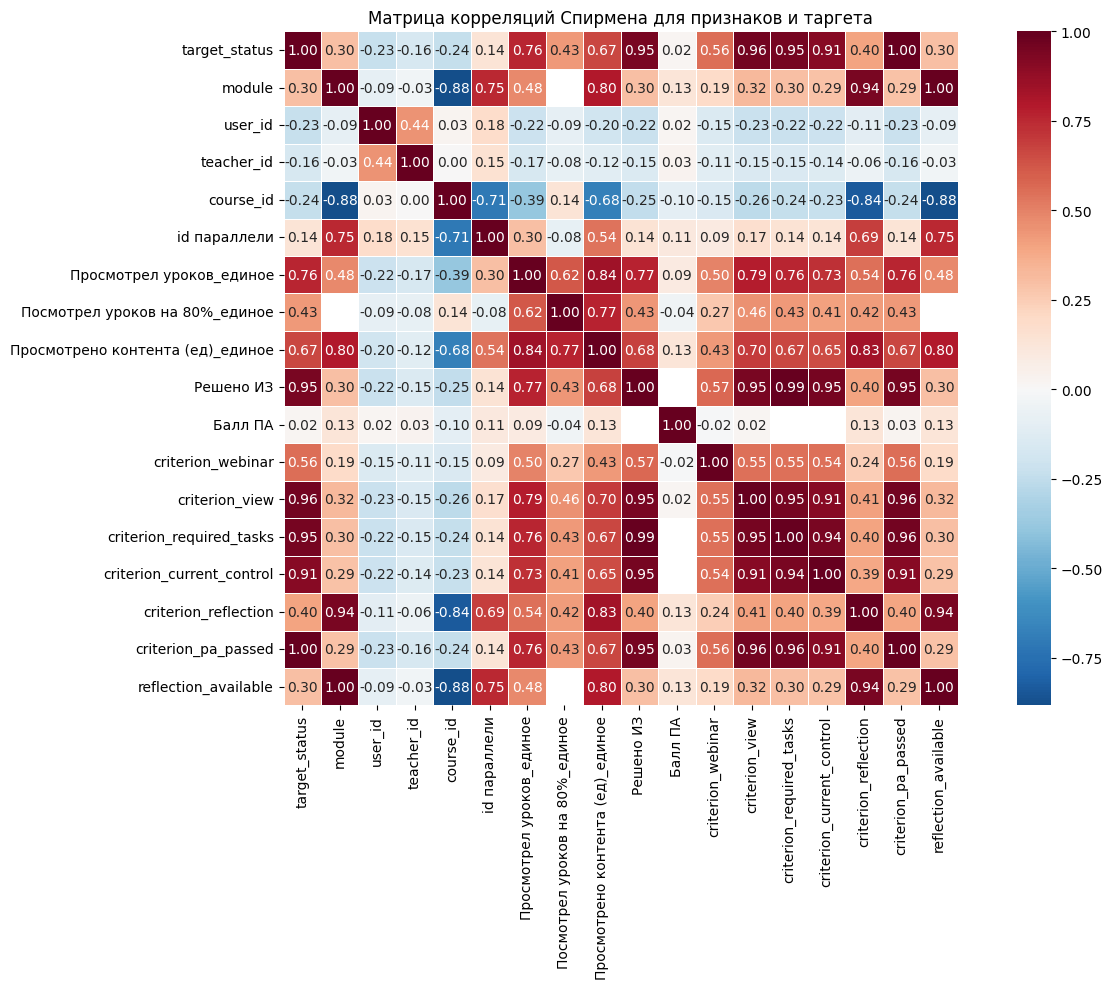

In [17]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Матрица корреляций Спирмена для признаков и таргета")
plt.tight_layout()
plt.show()

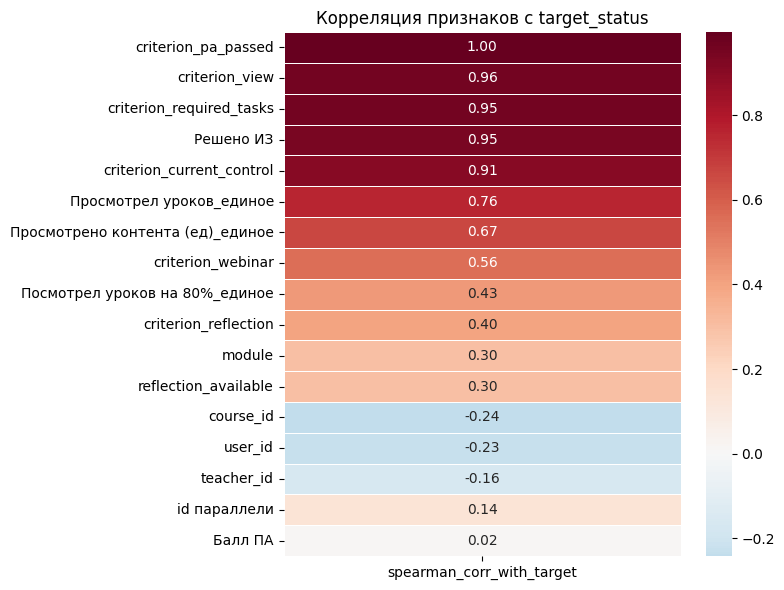

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    target_corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
)
plt.title("Корреляция признаков с target_status")
plt.tight_layout()
plt.show()

По этой матрице уже можно увидеть, какие признаки сильнее всего связаны со статусом. Ожидаемо, наибольшая связь должна быть у признаков, связанных с ПА и выполнением обязательных требований. 

Топ этих признаков - то, что нам надо восстановить из данных LMS